# 02 | Hiệu năng, LODO và ablation

Reused subject-held-out window metrics → confusion matrices hồi cứu → PPG_AC / PAC-PVC → DeepBeat failure modes.

**Nguồn:** [HealthSense MachineLearning Lab](https://github.com/HealthSense-IUH/HealthSense-MachineLearning-Lab) ở commit chốt trong manifest. **Chỉ đọc artifact**, không fit lại model và không ghi đè freeze.

In [1]:
import sys
from pathlib import Path
import os
_candidates=[Path.cwd(), Path.cwd()/'notebooks'/'HealthSense_Defense_Evidence_Notebooks', Path.cwd()/'HealthSense_Defense_Evidence_Notebooks']
if os.getenv('HEALTHSENSE_NOTEBOOK_DIR'): _candidates.insert(0,Path(os.environ['HEALTHSENSE_NOTEBOOK_DIR']).expanduser())
for _p in _candidates:
    if (_p/'healthsense_evidence_utils.py').is_file(): sys.path.insert(0,str(_p.resolve())); break
from healthsense_evidence_utils import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('REPO:',ROOT,'\nOUT:',OUT)
print('GIT:',git_info())

REPO: /home/phuc/Documents/HealthSense_rungtamnhi 
OUT: /home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T062905_803986Z
GIT: {'head': '1b9d9094cddb6f7fbe95e1f31fd969f0c537e22e', 'status_porcelain': '?? ": update README with V5 V6 datasets and references\\""\n?? experiments/02_beat_detector/official_detector_results.csv\n?? experiments/02_beat_detector/official_detector_summary.csv\n?? experiments/02_beat_detector/run_official_detectors.m\n?? experiments/02_beat_detector/score_official_detectors.py\n?? experiments/02_beat_detector/test_msptdfast.m\n?? experiments/02_beat_detector/test_msptdfast_peaks.csv\n?? experiments/02_beat_detector/test_ppg.csv\n?? experiments/02_beat_detector/test_qppgfast.m\n?? experiments/02_beat_detector/test_qppgfast_peaks.csv\n?? experiments/06_external_validation/audit_liu_dataset.py\n?? experiments/06_external_validation/audit_liu_signal.py\n?? experiments/06_external_validation/deepbeat_duplicate_overlap_audit.py\n?

## 1. Reused subject-held-out metrics + subject-cluster 95% CI
Đồ thị này là **replot bảng bootstrap đã lưu**. Không gọi đây là untouched external validation. Không dựng đường ROC/PR từ AUROC đơn lẻ.

metric,dataset,AUROC,Brier,ECE,PR_AUC
0,deepbeat,0.990391,0.058315,0.097791,0.988966
1,liu,0.986624,0.032217,0.016981,0.977976
2,pulsewatch,0.998465,0.009483,0.028895,0.988954


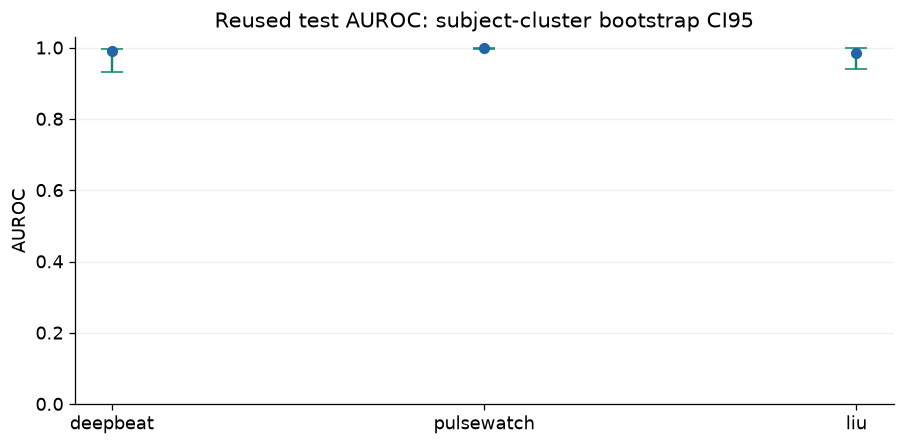

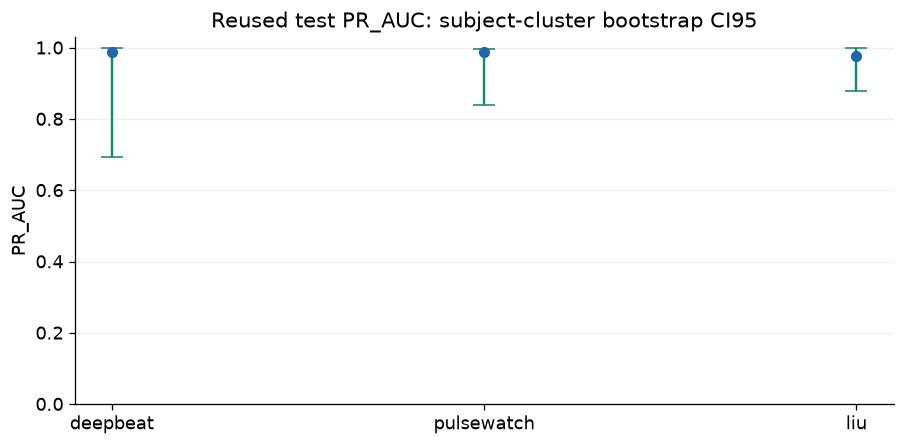

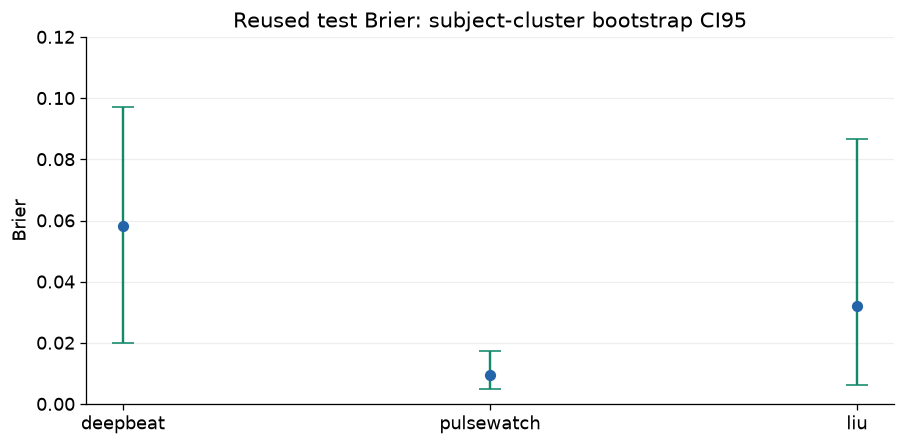

In [2]:
A=EVIDENCE_PREFIX
ci=csv(A+'window_metrics_subject_cluster_bootstrap.csv'); raw=ci[(ci.method=='RAW')&(ci.split=='REUSED_TEST')]
p=raw.pivot(index='dataset',columns='metric',values='point_estimate').reset_index();table(p,'01_reused_test_metrics')
for metric in ['AUROC','PR_AUC','Brier']:
    d=raw[raw.metric==metric].set_index('dataset').reindex(['deepbeat','pulsewatch','liu']).reset_index()
    y=d.point_estimate.to_numpy(); low=y-d.CI95_low.to_numpy();hi=d.CI95_high.to_numpy()-y
    fig,ax=plt.subplots(figsize=(8,4));ax.errorbar(d.dataset,y,yerr=[low,hi],fmt='o',capsize=7,color=BLUE,ecolor=GREEN);ax.set_ylabel(metric);ax.set_title(f'Reused test {metric}: subject-cluster bootstrap CI95');ax.set_ylim(bottom=0,top=1.03 if metric!='Brier' else max(.12,max(d.CI95_high)*1.15));ax.grid(axis='y',alpha=.2);figure(fig,'01_reused_'+metric.lower())

## 2. Tái tính Sensitivity / Specificity / Accuracy từ confusion counts
LODO là **retraining theo leave-one-domain-out**, không phải chỉ thay threshold của một model. Tất cả bốn domain đều phải được trình bày. Accuracy tính từ `(TP+TN)/(TP+TN+FP+FN)`.

,domain,subjects,windows,AUROC,PR_AUC,Brier,TP,TN,FP,FN,N,sensitivity,specificity,accuracy,precision,F1,balanced_accuracy
0,DEEPBEAT,128,25230,0.838364,0.828943,0.189850,5546,14297,497,4890,25230,0.531430,0.966405,0.786484,0.917756,0.673099,0.748917
1,PULSEWATCH,106,156978,0.987738,0.941706,0.056003,23156,124331,8606,885,156978,0.963188,0.935263,0.939539,0.729047,0.829920,0.949225
2,LIU,45,6280,0.979742,0.959866,0.050021,2645,3250,318,67,6280,0.975295,0.910874,0.938694,0.892676,0.932159,0.943085
3,MIMIC_PERFORM,35,4130,0.985598,0.986694,0.052994,2029,1803,85,213,4130,0.904996,0.954979,0.927845,0.959792,0.931589,0.929987


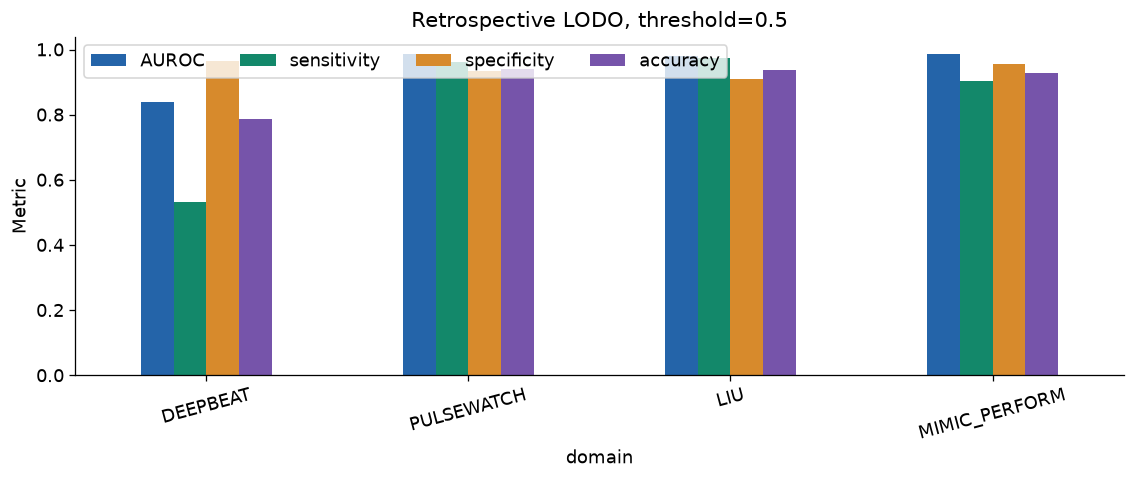

PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T062905_803986Z/02_lodo_all_domains.png')

In [3]:
lodo=csv(A+'lodo_domain_generalization_summary.csv')
rows=[]
for _,r in lodo.iterrows():
    m=confusion_metrics(r.TP,r.TN,r.FP,r.FN)
    assert m['N']==int(r.eval_rows), f'Confusion counts mismatch {r.heldout_domain}'
    assert_close(m['sensitivity'],r['sensitivity_at_0.5'],msg=r.heldout_domain+' sensitivity')
    assert_close(m['specificity'],r['specificity_at_0.5'],msg=r.heldout_domain+' specificity')
    rows.append({'domain':r.heldout_domain,'subjects':r.eval_subjects,'windows':r.eval_rows,'AUROC':r.AUROC,'PR_AUC':r.PR_AUC,'Brier':r.Brier,**m})
result=pd.DataFrame(rows);table(result,'02_lodo_recomputed_confusions')
fig,ax=plt.subplots(figsize=(10,4.3));data=result.set_index('domain')[['AUROC','sensitivity','specificity','accuracy']];data.plot.bar(ax=ax,color=[BLUE,GREEN,ORANGE,PURPLE]);ax.set_ylim(0,1.04);ax.set_ylabel('Metric');ax.tick_params(axis='x',rotation=15);ax.set_title('Retrospective LODO, threshold=0.5');ax.legend(ncol=4);figure(fig,'02_lodo_all_domains')

## 3. Confusion matrix của từng LODO domain
Các số là **window-level**, không thay cho patient-level clinical metrics.

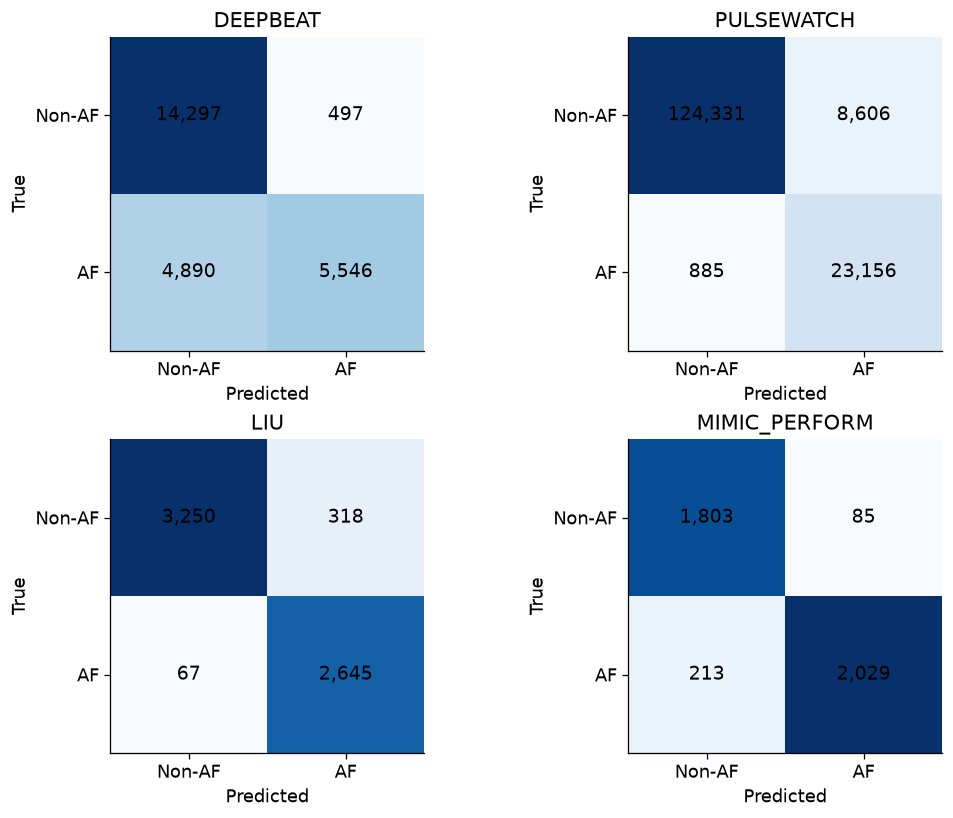

In [4]:
fig,axs=plt.subplots(2,2,figsize=(9,7),constrained_layout=True)
for ax,(_,r) in zip(axs.flat,result.iterrows()):
    mat=np.array([[r.TN,r.FP],[r.FN,r.TP]],dtype=int);ax.imshow(mat,cmap='Blues')
    for (i,j),v in np.ndenumerate(mat):ax.text(j,i,f'{v:,}',ha='center',va='center',color='black',fontsize=12)
    ax.set(xticks=[0,1],yticks=[0,1],xticklabels=['Non-AF','AF'],yticklabels=['Non-AF','AF'],xlabel='Predicted',ylabel='True',title=str(r.domain))
fig.savefig(OUT/'03_lodo_confusions.png',dpi=190,bbox_inches='tight');fig.savefig(OUT/'03_lodo_confusions.pdf',bbox_inches='tight');PLOTS.append('03_lodo_confusions');display(fig);plt.close(fig)

## 4. Reused-test confusion: CHỈ khi có đúng locked predictions local
Các CSV prediction của ba reused TEST không nằm trong Git snapshot. Nếu thiếu, notebook đánh dấu **MISSING**, tuyệt đối không suy ra sensitivity/specificity từ AUROC.

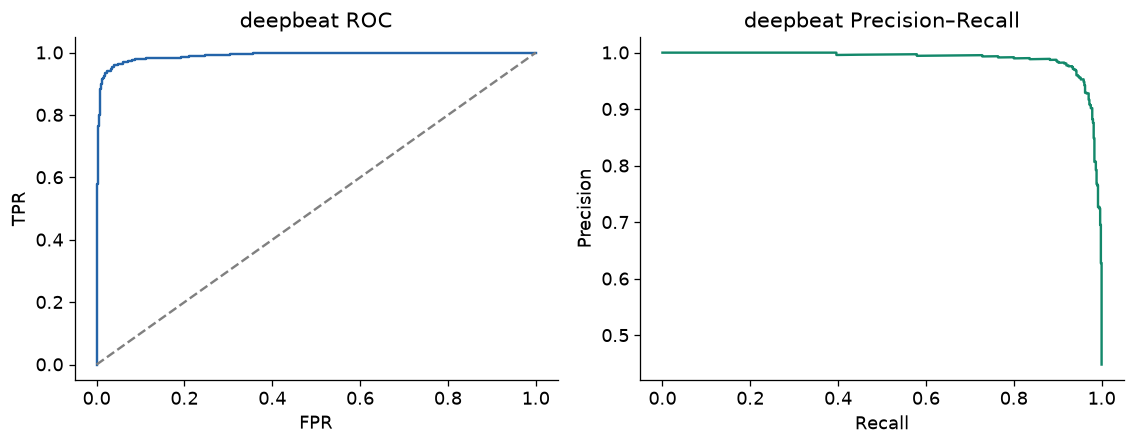

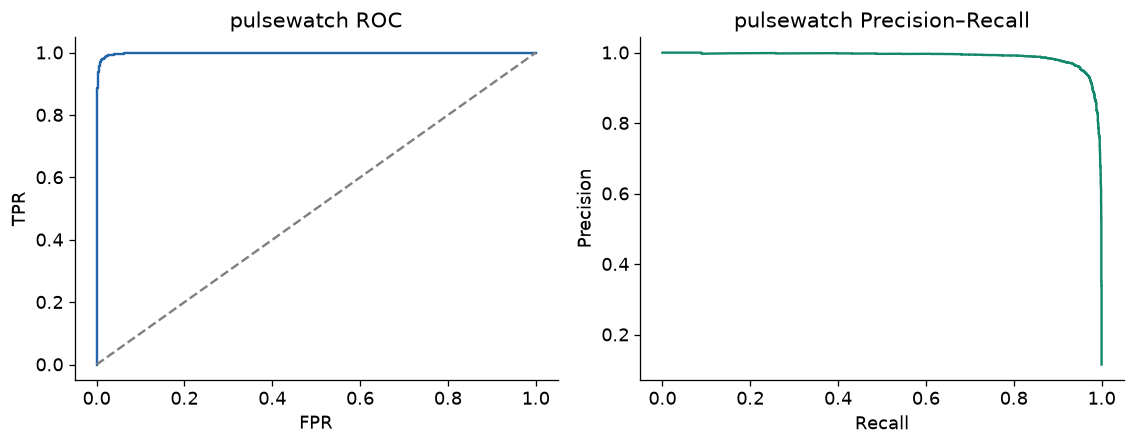

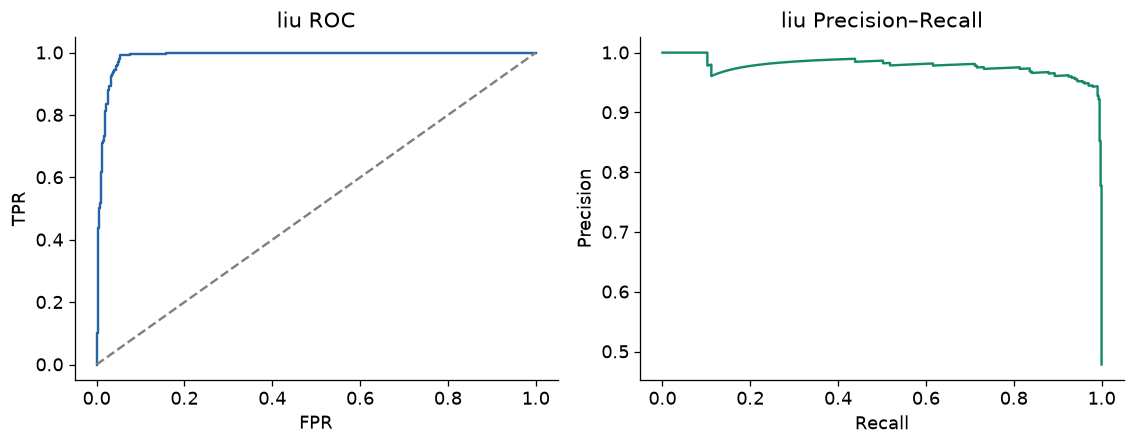

,TP,TN,FP,FN,N,sensitivity,specificity,accuracy,precision,F1,balanced_accuracy,dataset,status,AUROC,PR_AUC,Brier
0,600,645,107,11,1363,0.981997,0.857713,0.913426,0.848656,0.910470,0.919855,deepbeat,MATCHED_FROZEN_SHA256,0.990391,0.988966,0.058315
1,3362,26457,229,110,30158,0.968318,0.991419,0.988759,0.936229,0.952003,0.979868,pulsewatch,MATCHED_FROZEN_SHA256,0.998465,0.988954,0.009483
2,436,450,30,4,920,0.990909,0.937500,0.963043,0.935622,0.962472,0.964205,liu,MATCHED_FROZEN_SHA256,0.986624,0.977976,0.032217


PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T062905_803986Z/04_reused_test_optional_confusion.csv')

In [5]:
from sklearn.metrics import roc_auc_score,average_precision_score,brier_score_loss,roc_curve,precision_recall_curve
pred_rows=[]
for d in ['deepbeat','pulsewatch','liu']:
    rel=A+f'{d}_test_locked_predictions.csv'
    pred=csv(rel,required=False)
    if pred is None:
        pred_rows.append({'dataset':d,'status':'MISSING_PREDICTIONS'});continue
    # Freeze manifest contains expected sha256; reject mismatches rather than silently plotting.
    checksum_file=source(A+'locked_inputs_SHA256.txt',required=True)
    expected={line.split(maxsplit=1)[1].strip():line.split()[0] for line in checksum_file.read_text().splitlines() if line.strip()}
    if rel not in expected or sha256(ROOT/rel)!=expected[rel]:raise ValueError(f'Frozen checksum mismatch: {rel}')
    m=metric_from_predictions(pred)
    y=pred.label.astype(int);pr=pred.meta_probability.astype(float)
    m.update({'dataset':d,'status':'MATCHED_FROZEN_SHA256','AUROC':roc_auc_score(y,pr),'PR_AUC':average_precision_score(y,pr),'Brier':brier_score_loss(y,pr)})
    pred_rows.append(m)
    fpr,tpr,_=roc_curve(y,pr);prec,rec,_=precision_recall_curve(y,pr)
    fig,ax=plt.subplots(1,2,figsize=(10,4));ax[0].plot(fpr,tpr,color=BLUE);ax[0].plot([0,1],[0,1],'--',color='gray');ax[0].set(title=d+' ROC',xlabel='FPR',ylabel='TPR');ax[1].plot(rec,prec,color=GREEN);ax[1].set(title=d+' Precision–Recall',xlabel='Recall',ylabel='Precision');figure(fig,f'04_local_predictions_{d}')
table(pd.DataFrame(pred_rows),'04_reused_test_optional_confusion')

## 4a. Bảng chỉ số đầy đủ của reused subject-held-out TEST
**Không gọi đây là full LOSO trên toàn bộ người.** Ba tập DeepBeat, PulseWatch và Liu dùng subject-disjoint TEST; model đã được phát triển với các nguồn này. Những chỉ số dưới đây được tính lại từ đúng `*_test_locked_predictions.csv` và xác minh SHA256 ở cell trước. Cột `Recall` = Sensitivity tại ngưỡng 0.5. Không so sánh trực tiếp với LODO như thể hai protocol dùng cùng nhóm người và cùng model fit.


,dataset,N,TP,TN,FP,FN,accuracy_at_0.5,precision_at_0.5,recall,f1_at_0.5,specificity_at_0.5,AUROC,PR_AUC,Brier,status
0,deepbeat,1363,600,645,107,11,0.913426,0.848656,0.981997,0.910470,0.857713,0.990391,0.988966,0.058315,MATCHED_FROZEN_SHA256
1,pulsewatch,30158,3362,26457,229,110,0.988759,0.936229,0.968318,0.952003,0.991419,0.998465,0.988954,0.009483,MATCHED_FROZEN_SHA256
2,liu,920,436,450,30,4,0.963043,0.935622,0.990909,0.962472,0.937500,0.986624,0.977976,0.032217,MATCHED_FROZEN_SHA256


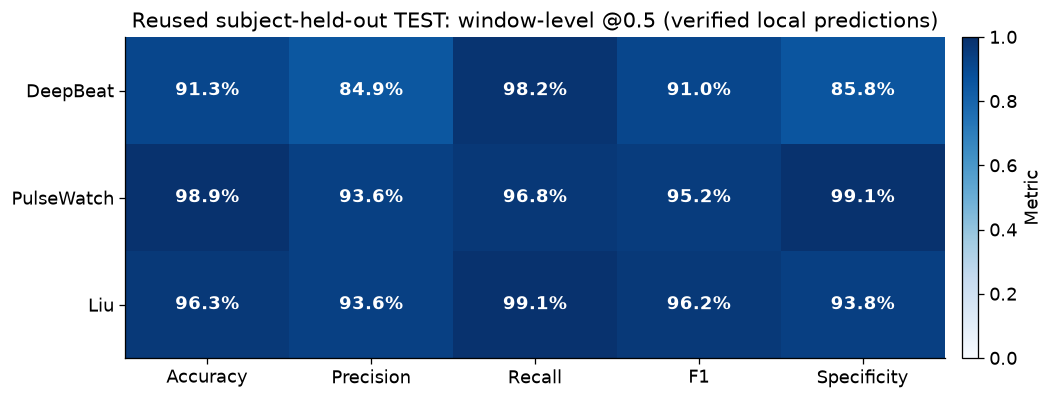

In [6]:
# Re-render full threshold metrics already computed from checksum-verified local predictions.
full=pd.DataFrame(pred_rows).copy()
ready=full[full.status.eq('MATCHED_FROZEN_SHA256')].copy()
if len(ready)!=3 or set(ready.dataset)!={'deepbeat','pulsewatch','liu'}:
    print('NOT COMPLETE: Để xuất bảng subject-held-out đầy đủ, cần 3 locked TEST prediction CSV khớp SHA256. Không điền số bằng tay.')
    display(full[['dataset','status']])
else:
    ready=ready.set_index('dataset').loc[['deepbeat','pulsewatch','liu']].reset_index()
    ready=ready.rename(columns={'sensitivity':'recall','precision':'precision_at_0.5',
                                'accuracy':'accuracy_at_0.5','specificity':'specificity_at_0.5','F1':'f1_at_0.5'})
    cols=['dataset','N','TP','TN','FP','FN','accuracy_at_0.5','precision_at_0.5','recall',
          'f1_at_0.5','specificity_at_0.5','AUROC','PR_AUC','Brier','status']
    ready=ready[cols]
    table(ready,'04b_subject_heldout_all_metrics')
    show=['accuracy_at_0.5','precision_at_0.5','recall','f1_at_0.5','specificity_at_0.5']
    x=ready[show].to_numpy(dtype=float)
    fig,ax=plt.subplots(figsize=(9.3,3.6))
    im=ax.imshow(x,vmin=0,vmax=1,cmap='Blues',aspect='auto')
    ax.set_xticks(range(len(show)),['Accuracy','Precision','Recall','F1','Specificity'])
    ax.set_yticks(range(len(ready)),['DeepBeat','PulseWatch','Liu'])
    for i in range(len(ready)):
        for j in range(len(show)):
            ax.text(j,i,f'{x[i,j]:.1%}',ha='center',va='center',
                    color='white' if x[i,j]>=.65 else 'black',fontsize=11,weight='bold')
    ax.set_title('Reused subject-held-out TEST: window-level @0.5 (verified local predictions)')
    fig.colorbar(im,ax=ax,fraction=.035,pad=.02,label='Metric')
    figure(fig,'04b_subject_heldout_threshold_metrics')


## 4b. Phân biệt ba loại kết quả trước khi bảo vệ
- **Subject-held-out TEST hiện tại:** 3 domain trong bảng 4a; chỉ là một subset người mỗi domain, không phải full LOSO.
- **LODO hiện tại:** toàn bộ domain được loại khỏi cả training và meta-training; dùng `lodo_domain_generalization_summary.csv`, 4 domain.
- **MIMIC LOSO lịch sử:** benchmark baseline theo từng người; không phải kết quả của model stacking frozen hiện tại.
Các bảng giữ riêng từng protocol; không gộp/macro-average giữa chúng.


In [7]:
# LODO has its own retrained model per domain and complete confusion counts in the locked artifact.
lodo_full=result[['domain','subjects','windows','TP','TN','FP','FN','accuracy','precision',
                  'sensitivity','F1','specificity','AUROC','PR_AUC','Brier']].copy()
lodo_full=lodo_full.rename(columns={'sensitivity':'recall'})
table(lodo_full,'04c_lodo_all_metrics')

# Historical MIMIC LOSO baseline: not the current frozen stacking model.
hist=csv('experiments/00_baseline_reproduction/artifacts/benchmark_results_v4.csv')
hist=hist.loc[hist.Level.eq('subject')].copy()
rows=[]
for _,r in hist.iterrows():
    m=confusion_metrics(r.TP,r.TN,r.FP,r.FN)
    assert_close(m['accuracy'],r.Accuracy,msg='Historical MIMIC '+r.Model+' accuracy')
    assert_close(m['sensitivity'],r['Recall (Sensitivity)'],msg='Historical MIMIC '+r.Model+' recall')
    rows.append({'historical_model':r.Model,'subjects':m['N'],'TP':m['TP'],'TN':m['TN'],
                 'FP':m['FP'],'FN':m['FN'],'accuracy':m['accuracy'],'precision':m['precision'],
                 'recall':m['sensitivity'],'F1':m['F1'],'specificity':m['specificity'],
                 'AUROC':r['ROC-AUC'],'protocol':'HISTORICAL_MIMIC_LOSO_BASELINE_NOT_FROZEN_STACKING'})
table(pd.DataFrame(rows),'04d_historical_mimic_loso_subject_metrics')


,domain,subjects,windows,TP,TN,FP,FN,accuracy,precision,recall,F1,specificity,AUROC,PR_AUC,Brier
0,DEEPBEAT,128,25230,5546,14297,497,4890,0.786484,0.917756,0.531430,0.673099,0.966405,0.838364,0.828943,0.189850
1,PULSEWATCH,106,156978,23156,124331,8606,885,0.939539,0.729047,0.963188,0.829920,0.935263,0.987738,0.941706,0.056003
2,LIU,45,6280,2645,3250,318,67,0.938694,0.892676,0.975295,0.932159,0.910874,0.979742,0.959866,0.050021
3,MIMIC_PERFORM,35,4130,2029,1803,85,213,0.927845,0.959792,0.904996,0.931589,0.954979,0.985598,0.986694,0.052994


,historical_model,subjects,TP,TN,FP,FN,accuracy,precision,recall,F1,specificity,AUROC,protocol
0,Logistic Regression,35,19,14,2,0,0.942857,0.904762,1.0,0.95,0.875,0.875000,HISTORICAL_MIMIC_LOSO_BASELINE_NOT_FROZEN_STAC...
1,Random Forest,35,19,14,2,0,0.942857,0.904762,1.0,0.95,0.875,0.930921,HISTORICAL_MIMIC_LOSO_BASELINE_NOT_FROZEN_STAC...
2,XGBoost,35,19,14,2,0,0.942857,0.904762,1.0,0.95,0.875,0.901316,HISTORICAL_MIMIC_LOSO_BASELINE_NOT_FROZEN_STAC...


PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T062905_803986Z/04d_historical_mimic_loso_subject_metrics.csv')

## 5. Matched ablation 13 vs 14 đặc trưng
Cùng cohort DEV; báo cáo macro (không gộp toàn bộ windows rồi xem như một domain). Highlight các chỉ số có hướng tốt ngược nhau.

,variant,dataset,n_features,rows,subjects,AUROC,PR_AUC,Brier
0,13F_NO_PPG_AC,deepbeat,13,4026,13,0.778556,0.274198,0.147950
1,13F_NO_PPG_AC,pulsewatch,13,17679,16,0.986941,0.916362,0.032327
2,13F_NO_PPG_AC,liu,13,997,7,0.980612,0.662024,0.038411
3,14F_WITH_PPG_AC,deepbeat,14,4026,13,0.807113,0.426610,0.110630
4,14F_WITH_PPG_AC,pulsewatch,14,17679,16,0.990568,0.938564,0.028477
5,14F_WITH_PPG_AC,liu,14,997,7,0.981312,0.642643,0.042878


,variant,macro_AUROC,macro_PR_AUC,macro_Brier
0,13F_NO_PPG_AC,0.915370,0.617528,0.072896
1,14F_WITH_PPG_AC,0.926331,0.669272,0.060662


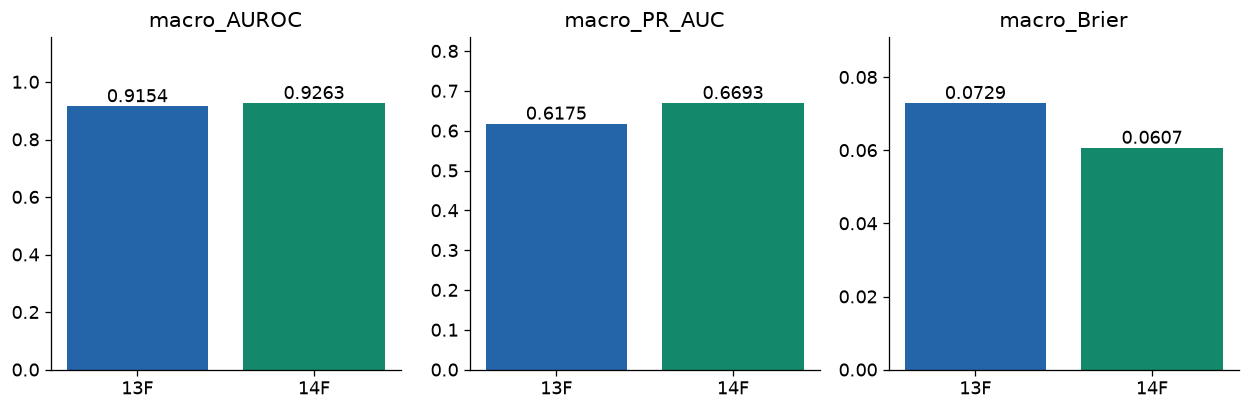

PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T062905_803986Z/05_ppg_ac_macro_ablation.png')

In [8]:
ab=csv(A+'ppg_ac_ablation_dev_summary.csv');macro=csv(A+'ppg_ac_ablation_dev_macro.csv');table(ab,'05_ablation_domain');display(macro)
fig,axs=plt.subplots(1,3,figsize=(11,3.7));metrics=['macro_AUROC','macro_PR_AUC','macro_Brier']
for ax,m in zip(axs,metrics):
    v=macro[m].to_numpy();ax.bar(['13F','14F'],v,color=[BLUE,GREEN]);ax.set_title(m);ax.set_ylim(0,max(v)*1.25)
    for i,z in enumerate(v):ax.text(i,z,f'{z:.4f}',ha='center',va='bottom')
figure(fig,'05_ppg_ac_macro_ablation')

## 6. DeepBeat held-out ablation: trade-off ở ngưỡng 0.5

,variant,split,rows,subjects,AUROC,PR_AUC,Brier,TP,TN,FP,FN,sensitivity,specificity
0,13F_NO_PPG_AC,ALL_DEEPBEAT,25230,128,0.813611,0.757496,0.203322,5808,13239,1555,4628,0.556535,0.894890
4,14F_WITH_PPG_AC,ALL_DEEPBEAT,25230,128,0.838364,0.828943,0.189850,5546,14297,497,4890,0.531430,0.966405


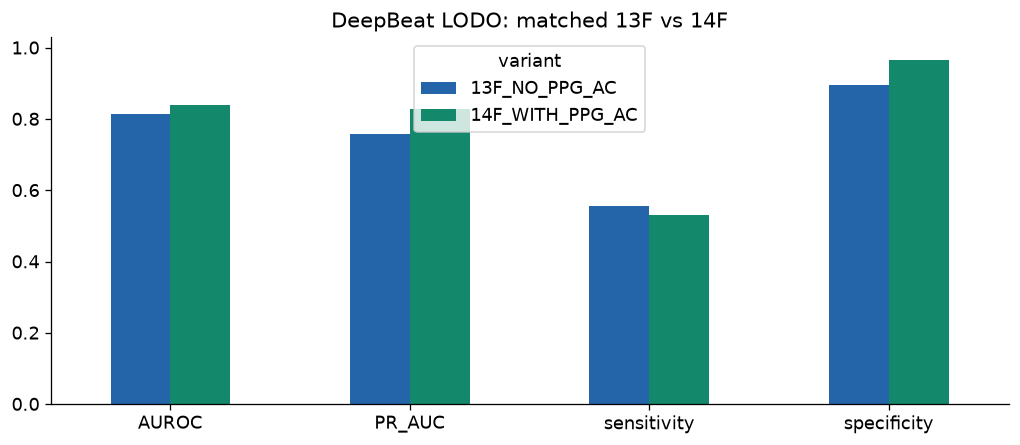

PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T062905_803986Z/06_deepbeat_matched_tradeoff.png')

In [9]:
d=csv(A+'deepbeat_lodo_ppg_ac_ablation_summary.csv');d=d[d.split=='ALL_DEEPBEAT'];display(d)
fig,ax=plt.subplots(figsize=(9,4));p=d.set_index('variant')[['AUROC','PR_AUC','sensitivity','specificity']];p.T.plot.bar(ax=ax,color=[BLUE,GREEN]);ax.set_ylim(0,1.03);ax.set_title('DeepBeat LODO: matched 13F vs 14F');ax.tick_params(axis='x',rotation=0);figure(fig,'06_deepbeat_matched_tradeoff')

## 7. PAC/PVC hard negatives: false-positive **windows**, không phải alerts/person

,challenge,windows,mean_probability,median_probability,p90_probability,p95_probability,max_probability,mean_ensemble_std,FP_count_ge_0_5,FPR_ge_0_5,FP_count_ge_0_7,FPR_ge_0_7,FP_count_ge_0_8,FPR_ge_0_8,FP_count_ge_0_9,FPR_ge_0_9,FP_count_ge_0_95,FPR_ge_0_95
0,PULSEWATCH_PAC_PVC_TEST,264,0.082660,0.032231,0.159851,0.398831,0.937072,0.038658,12,0.045455,8,0.030303,4,0.015152,2,0.007576,0,0.00
1,PEAKDET_PAC_PVC,50,0.222393,0.062805,0.922211,0.941501,0.955827,0.074366,9,0.180000,9,0.180000,7,0.140000,6,0.120000,2,0.04


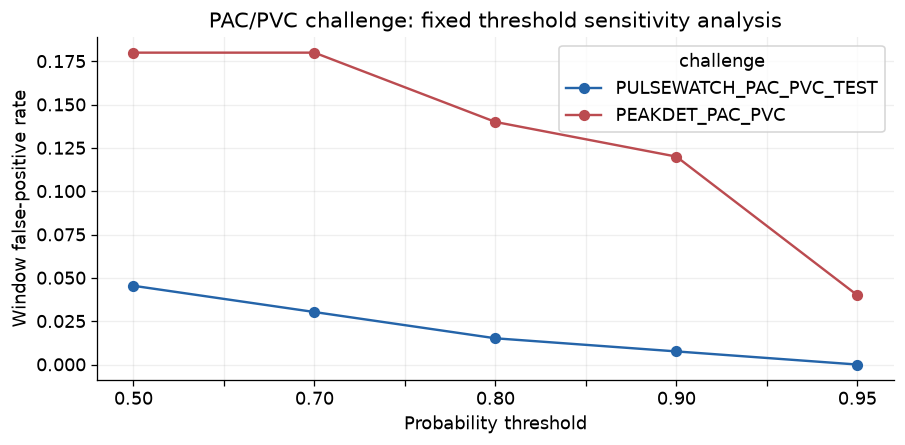

PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T062905_803986Z/07_hard_negative_fpr.png')

In [10]:
challenge=csv(A+'pac_pvc_challenge_summary.csv');table(challenge,'07_pac_pvc_raw')
col=['FPR_ge_0_5','FPR_ge_0_7','FPR_ge_0_8','FPR_ge_0_9','FPR_ge_0_95'];v=challenge.set_index('challenge')[col].T;v.index=['0.50','0.70','0.80','0.90','0.95']
fig,ax=plt.subplots(figsize=(8,4));v.plot(ax=ax,marker='o',color=[BLUE,RED]);ax.set(xlabel='Probability threshold',ylabel='Window false-positive rate',title='PAC/PVC challenge: fixed threshold sensitivity analysis');ax.grid(alpha=.2);figure(fig,'07_hard_negative_fpr')

## 8. Failure mode và base learner so sánh trong DeepBeat LODO
FN-vs-TP là **quan sát có điều kiện trong đánh giá hồi cứu**, không khẳng định cơ chế gây bệnh hoặc độc lập mẫu bệnh nhân.

,model,AUROC,PR_AUC,Brier,sensitivity,specificity
0,STACK,0.838364,0.828943,0.189850,0.531430,0.966405
1,ExtraTrees,0.838765,0.823979,0.173431,0.558356,0.957618
2,RandomForest,0.841659,0.828467,0.167220,0.577712,0.954103
3,XGBoost,0.833521,0.823660,0.187716,0.542353,0.958632


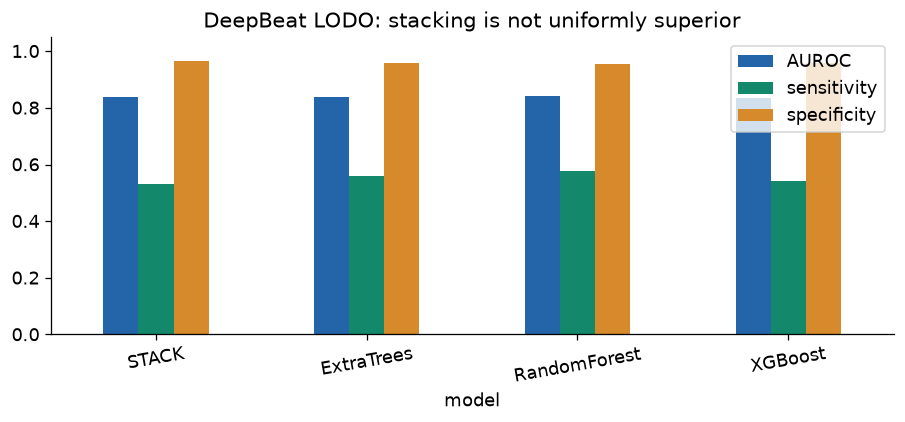

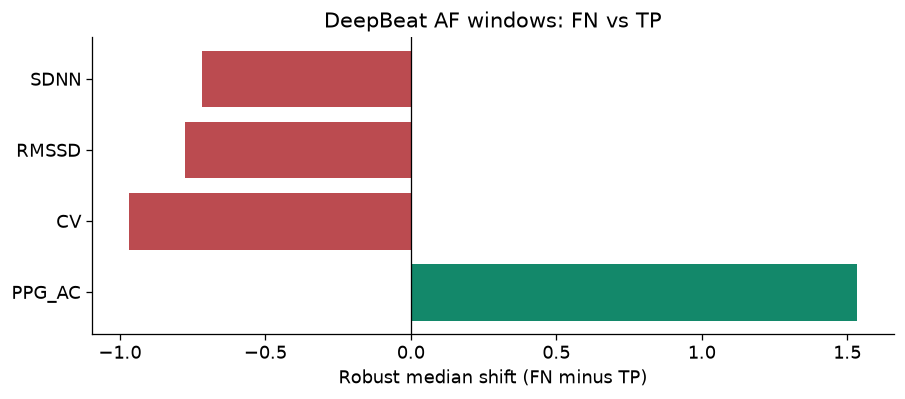

,feature,TP_n,FN_n,TP_median,FN_median,FN_minus_TP_robust_shift,abs_shift,KS_statistic,KS_pvalue
0,PPG_AC,5546,4890,0.070384,0.181569,1.533817,1.533817,0.740280,0.000000e+00
1,CV,5546,4890,0.288514,0.175494,-0.969579,0.969579,0.502193,0.000000e+00
2,NN50,5546,4890,26.000000,19.000000,-0.933333,0.933333,0.515690,0.000000e+00
3,pNN50,5546,4890,87.804878,71.834936,-0.784323,0.784323,0.526469,0.000000e+00
4,RMSSD,5546,4890,310.242794,210.217651,-0.777781,0.777781,0.416029,8.942588e-322
5,SD1,5546,4890,223.004527,151.474413,-0.770122,0.770122,0.413139,1.170936e-321
6,SampEn,5546,4890,0.000000,0.961411,0.739764,0.739764,0.313061,1.616083e-225
7,Total_Power,5546,4890,29832.278248,8507.135580,-0.735012,0.735012,0.421143,4.100745e-322
8,SDNN,5546,4890,226.751499,152.132046,-0.718085,0.718085,0.407211,1.724289e-321
9,HF,5546,4890,17764.840027,5681.158881,-0.699150,0.699150,0.404495,1.981203e-321


PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T062905_803986Z/09_deepbeat_fn_tp_features.csv')

In [11]:
bases=csv(A+'deepbeat_lodo_base_vs_stack.csv');display(bases[['model','AUROC','PR_AUC','Brier','sensitivity','specificity']]);fig,ax=plt.subplots(figsize=(8,3.8));bases.set_index('model')[['AUROC','sensitivity','specificity']].plot.bar(ax=ax,color=[BLUE,GREEN,ORANGE]);ax.set_ylim(0,1.05);ax.set_title('DeepBeat LODO: stacking is not uniformly superior');ax.tick_params(axis='x',rotation=10);figure(fig,'08_base_vs_stack')
fn=csv(A+'deepbeat_lodo_fn_vs_tp_features.csv');subset=fn[fn.feature.isin(['PPG_AC','CV','RMSSD','SDNN'])].set_index('feature').loc[['PPG_AC','CV','RMSSD','SDNN']]
fig,ax=plt.subplots(figsize=(8,3.6));ax.barh(subset.index,subset.FN_minus_TP_robust_shift,color=[GREEN if v>=0 else RED for v in subset.FN_minus_TP_robust_shift]);ax.axvline(0,color='black',lw=.8);ax.set_xlabel('Robust median shift (FN minus TP)');ax.set_title('DeepBeat AF windows: FN vs TP');figure(fig,'09_fn_tp_shift');table(fn,'09_deepbeat_fn_tp_features')

In [12]:
manifest('02_Frozen_Metrics_LODO_and_Ablations', ['LODO: retrospective refitting per heldout domain','Reused test: previously inspected subject-held-out','ROC curves generated only from sha-matched local predictions, not from aggregate AUROC','Threshold=0.5 for confusion metrics; do not interpret as deployment operating point'])

Nguồn và checksum: /home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T062905_803986Z/02_Frozen_Metrics_LODO_and_Ablations_input_manifest.json
Biểu đồ: 14 | thư mục: /home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T062905_803986Z


PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T062905_803986Z/02_Frozen_Metrics_LODO_and_Ablations_input_manifest.json')